In [70]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [72]:
def CalcEMA(NOP, dataC):
    sf = 2 / (NOP + 1)
    EMA = []
    EMA.append((dataC[0]) * sf)
    temp = (dataC[0]) * sf

    for i in range(1, len(dataC)):
        ema = dataC[i] * sf + temp * (1 - sf)
        temp = ema
        EMA.append(ema)

    return EMA

In [75]:
data = yf.download('MSFT', start='2021-05-23', end='2023-05-23', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [76]:
macd = [emashort - emalong for (emashort, emalong) in zip(CalcEMA(12, data['Close']), CalcEMA(26, data['Close']))]
macd = np.array(macd)
signaline = CalcEMA(9 , macd)
hist = macd - np.array(signaline)

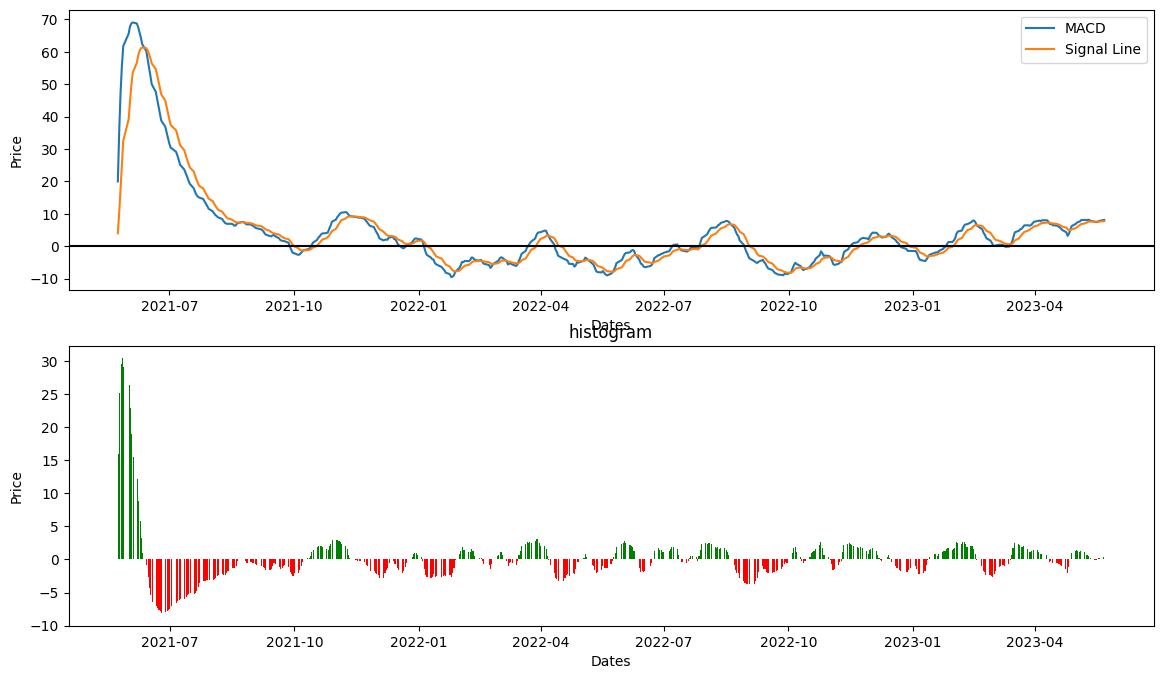

In [77]:
plt.figure(figsize=(14, 8))
plt.tight_layout()
plt.subplot(2 , 1 ,1)
plt.plot(data.index, macd)
plt.plot(data.index , signaline)
plt.xlabel('Dates')
plt.ylabel('Price')
plt.legend(loc='best', labels=['MACD', 'Signal Line'])
plt.axhline(0, color='black')
plt.subplot(2 , 1, 2)
diff = hist
colors = ['red' if d < 0 else 'green' for d in diff]
plt.title('histogram')
plt.bar(data.index, hist , color = colors)
plt.ylabel('Price')
plt.xlabel('Dates')
plt.show()
